<a href="https://colab.research.google.com/github/Navitapnchr/analisis-sentimen-imdb/blob/main/Analisis_Sentimen_IMDB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('IMDB Dataset.csv')

print(df.shape)

(50000, 2)


In [ ]:
df['clean_review'] = df['review'].apply(clean_text)

In [ ]:
df = df.sample(n=3000, random_state=42)

print(df.shape)

(3000, 3)


In [ ]:
import re
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()

    # hapus semua tag html
    text = re.sub(r'<.*?>', ' ', text)

    # sisakan huruf
    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return ' '.join(words)

df['clean_review'] = df['review'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
all_words = " ".join(df['clean_review'])

print(" br " in all_words)

True


In [ ]:
word_list = all_words.split()

print('br' in word_list)

True


In [ ]:
def clean_text(text):
    text = text.lower()

    text = re.sub(r'<.*?>', ' ', text)

    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    words = [w for w in words if w != 'br']

    return ' '.join(words)

In [ ]:
df['clean_review'] = df['review'].apply(clean_text)

all_words = " ".join(df['clean_review'])

print(" br " in all_words)

False


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['clean_review'])

y = df['sentiment']

print(X.shape)

(3000, 3000)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)

print(acc)

0.8483333333333334


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.84      0.86      0.85       292
    positive       0.86      0.84      0.85       308

    accuracy                           0.85       600
   macro avg       0.85      0.85      0.85       600
weighted avg       0.85      0.85      0.85       600



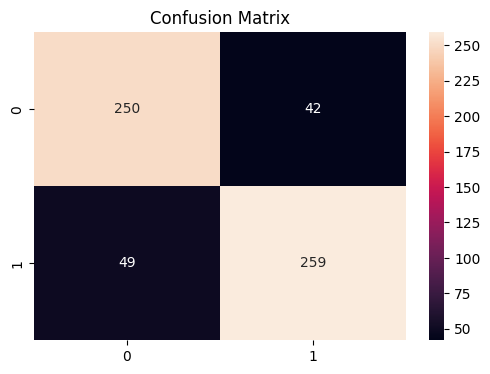

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.title('Confusion Matrix')
plt.show()

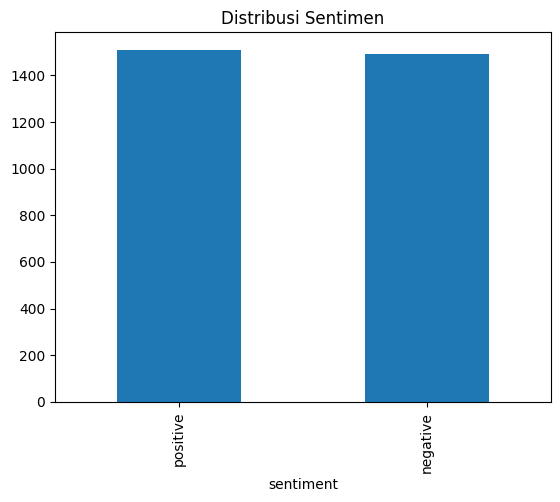

In [ ]:
df['sentiment'].value_counts().plot(kind='bar')

plt.title('Distribusi Sentimen')
plt.show()

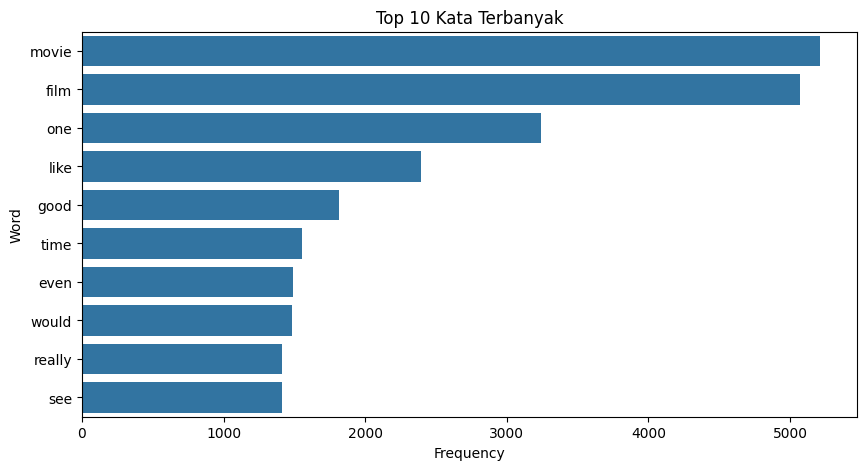

In [ ]:
from collections import Counter

all_words = " ".join(df['clean_review'])

words = all_words.split()

word_freq = Counter(words)

top_words = word_freq.most_common(10)

word_df = pd.DataFrame(
    top_words,
    columns=['Word','Frequency']
)

plt.figure(figsize=(10,5))

sns.barplot(
    x='Frequency',
    y='Word',
    data=word_df
)

plt.title('Top 10 Kata Terbanyak')
plt.show()